In [1]:
#%%
"""
sweep_santec_pm320e.py
Created on 2026-02-26
Author: Jan Scarabelli Calopa

New version of Lab_Codes/wavelength_sweep_santec.py to use 
with PM320E instead of PM100 
"""
import pyvisa
import qontrol
import tqdm
import clr
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ThorlabsPM100 import ThorlabsPM100
from Functions import *

rm = pyvisa.ResourceManager()

In [2]:
#%% Get list of connected devices
resources = rm.list_resources()
print(resources)  # Should list something like 'USB0::0x1313::0x8022::M00606447::INSTR', ...

('USB0::0x1313::0x8022::M00606447::INSTR', 'USB0::0x1313::0x8048::M00245549::INSTR', 'ASRL3::INSTR', 'ASRL11::INSTR', 'ASRL12::INSTR')


In [10]:
len(resources)

3

In [3]:
#%% Connect to PM320E
pm320e_name = 'USB0::0x1313::0x8022::M00606447::INSTR' # change if different PM
try:
    pm320e = rm.open_resource(pm320e_name)
    pm320e.write('POW2DBM')
    print("PM320E: Connection Successful!")
except Exception as e:
    print(f"PM320E: Connection error - {e}")

#%% Connect to PM100
pm100_name = "USB0::0x1313::0x8078::P0017921::0::INSTR" # PM100
try:
    r_pm100 = rm.open_resource(pm100_name)
    r_pm100.write('CONF:POW')
    pm100 = ThorlabsPM100(inst=r_pm100)
    pm100.timeout = 5000
    pm100.sense.correction.wavelength=1550
    print("PM100: Connection Successful!")

except Exception as e:
    print(f"PM100: Connection error - {e}")

#print(inst.query("*IDN?"))

PM320E: Connection Successful!
PM100: Connection error - VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.


In [16]:
# Temperature Controller

tc_name = 'USB0::0x1313::0x8048::M00245549::INSTR'

try:
    visaObj = VISADevice(tc_name)
    tempController = Thorlabs4000(visaObj)
    print("Temperature Controller: Connection Successful!")
    print(f"Current temperature: {tempController.read_temperature()} °C")
except Exception as e:
    print(f"Temperature Controller: Connection error - {e}")

Temperature Controller: Connection Successful!
Current temperature: 20.0036 °C


In [ ]:
def read_power_mW(pm, channel=None):
    """
    Reads the power from the power meter and converts it to mW.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        p_in_w = pm.query(f":POW{channel}:VAL?")
    except:
        try:
            # PM100
            p_in_w = pm.read
        except:
            raise ValueError("Could not read power from the power meter")

    
    p_in_mw = float(p_in_w) * 1e3  # Convert W to mW
    return p_in_mw

def read_power_dbm(pm, channel=None):
    """
    Reads the power from the power meter and converts it to dBm.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        p_in_w = pm.query(f":POW{channel}:VAL?")
    except:
        try:
            # PM100
            p_in_w = pm.read
        except:
            raise ValueError("Could not read power from the power meter")

    
    p_in_dbm = 10 * np.log10(float(p_in_w) * 1e3)  # Convert W to mW and then to dBm
    return p_in_dbm

def set_measuring_wavelength(pm, wavelength, channel=None):
    """
    Sets the measuring wavelength for the power meter.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        pm.write(f":WAVEL{channel}:VAL {wavelength}")  # Set wavelength for channel 1
    except:
        try:
            # PM100
            pm.sense.correction.wavelength = wavelength
        except:
            raise ValueError("Could not set measuring wavelength")
        


In [6]:
#%% Try to read power

try:
    p1_dbm = read_power_dbm(pm=pm320e, channel=1)
    print(f"PM320E Power in dBm: {p1_dbm}")
except Exception as e:
    print(f"Error reading PM320E power: {e}")

try:
    p2_dbm = read_power_dbm(pm=pm320e, channel=2)
    print(f"PM320E Power in dBm: {p2_dbm}")
except Exception as e:
    print(f"Error reading PM320E power: {e}")

print(f"Measured Power 1 in dBm: {p1_dbm}")
print(f"Measured Power 2 in dBm: {p2_dbm}")

PM320E Power in dBm: -4.583750651864295
PM320E Power in dBm: -23.17318155992861
Measured Power 1 in dBm: -4.583750651864295
Measured Power 2 in dBm: -23.17318155992861


In [6]:
# Laser turn ON
laser = SantecLaser(GPIB=28, timeout=10000)
laser.connect()
laser.turn_on()
laser.set_power(6)
laser.set_wavelength(1550)


VisaIOError: VI_ERROR_BERR (-1073807304): Bus error occurred during transfer.

In [ ]:
# Laser turn ON
laser = CobriteLaser(COM=11)
laser.connect()
laser.turn_on()
laser.set_power(6)
laser.set_wavelength(1550)

In [ ]:
laser.set_wavelength(1550)


In [ ]:
laser.turn_off()
laser.close()

In [ ]:
laser.query(f"DIT 0")

In [ ]:
laser.query(f"CONF?")

In [26]:
p_op_list = []
temp_list = []
for i in range (500):

    p_op = read_power_dbm(pm=pm320e, channel=2)
    temp = tempController.read_temperature()

    p_op_list.append(p_op)
    temp_list.append(temp)
    time.sleep(0.1)

In [ ]:
plt.figure(figsize=(8,5))

# Left axis (Power)
ax1 = plt.gca()
ax1.plot(p_op_list, marker='o', color='tab:blue', label='PM320E - In L-07 Out R-16')
ax1.set_xlabel('Obs')
ax1.set_ylabel('Power [dBm]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis (Temperature)
ax2 = ax1.twinx()
ax2.plot(temp_list, marker='o', color='tab:red', label='Temperature [°C]')
ax2.set_ylabel('Temperature [°C]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Time evolution of long AMZI - 0.1s intervals @ 20 °C')
0
# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

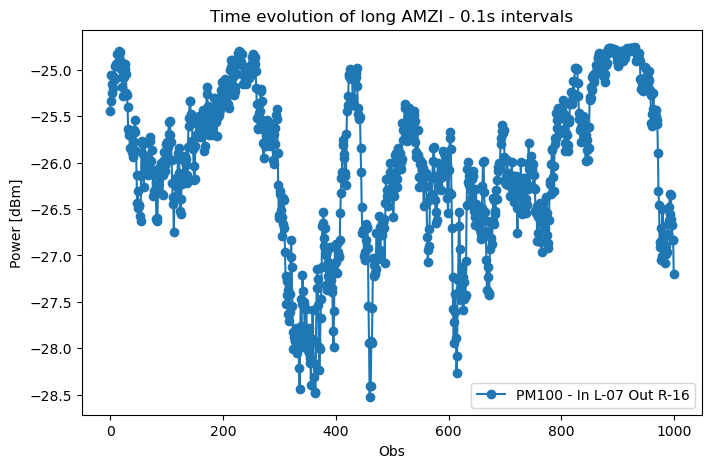

In [16]:
plt.figure(figsize=(8,5))
plt.plot(p_op, marker='o', label='PM100 - In L-07 Out R-16')
#plt.plot(wavelengths[:], powers_c2_dbm, marker='o', label='PM320E - 31_32')
plt.title('Time evolution of long AMZI - 0.1s intervals')
plt.xlabel('Obs')
plt.ylabel('Power [dBm]')
plt.legend(loc="lower right")
plt.show()

Wavelength Sweep

In [ ]:
# SINGLE MEASUREMENT PER WAVELENGTH

wavelengths = np.arange(1535, 1565, 0.5)
laser.set_wavelength(wavelengths[0])

powers_c1_dbm = []
powers_c2_dbm = []

time.sleep(1)
for wl in tqdm.tqdm(wavelengths):
    new_wl = round(float(wl),2)
    laser.set_wavelength(new_wl)
    laser.query(f"DIT 0")
    set_measuring_wavelength(pm=pm100, wavelength=new_wl, channel=None)
    set_measuring_wavelength(pm=pm320e, wavelength=new_wl, channel=2) 
    time.sleep(15)

    print(f"Set wavelength to {wl} nm, dither configuration: {laser.query(f'CONF?')}", end='\r')
    p_c1_dbm = read_power_dbm(pm=pm100, channel=None)
    p_c2_dbm = read_power_dbm(pm=pm320e, channel=2)

    powers_c1_dbm.append(p_c1_dbm) 
    powers_c2_dbm.append(p_c2_dbm)

    #print(f"Set wavelength to {wl} nm, measured power: {powers_c1_dbm[-1]:.2f} dBm   ", end='\r')


In [ ]:
read_power_dbm(pm=pm320e, channel=2)

In [ ]:
powers_c1_dbm

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(wavelengths, powers_c1_dbm, marker='o', label='PM100 - In L-07 Out R-15')
#plt.plot(wavelengths[:], powers_c2_dbm, marker='o', label='PM320E - 31_32')
plt.title('Corite WL Sweep AMZI-2 - 0.5nm/15s intervals')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Power [dBm]')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming wavelengths is a list/array
# Unpack the list of tuples (mean, std)
means = [val[0] for val in powers_c1_dbm]
stds = [val[1] for val in powers_c1_dbm]

# Convert to numpy arrays for easier math
means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(10, 6))

# 1. Plot the shaded error region (mean +/- std)
plt.fill_between(wavelengths, means - stds, means + stds, 
                 color='skyblue', alpha=0.3, label='$\pm 1\sigma$ Uncertainty')

# 2. Plot the main trend line
plt.plot(wavelengths, means, lw=1, marker='o', 
         markersize=4, label='PM100 Mean Power')

# Styling refinements
plt.title('Out 16 Wavelength Sweep', fontsize=14)
plt.xlabel('Wavelength [nm]', fontsize=12)
plt.ylabel('Power [dBm]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
wl = 1550
laser.set_wavelength()

powers_16_dbm = []
powers_17_dbm = []

time.sleep(2)
for wl in tqdm.tqdm(wavelengths):
    new_wl = round(float(wl),2)
    laser.set_wavelength(new_wl)
    set_measuring_wavelength(pm=pm100, wavelength=new_wl, channel=None)
    set_measuring_wavelength(pm=pm320e, wavelength=new_wl, channel=2) 
    time.sleep(1)

    # Wait for the laser to stabilize at the new wavelength
    p16_dbm = read_power_dbm(pm=pm100, channel=None)
    p17_dbm = read_power_dbm(pm=pm320e, channel=2)
    powers_16_dbm.append(p16_dbm) 
    powers_17_dbm.append(p17_dbm)
    #print(f"Set wavelength to {wl} nm, measured power: {powers_16_dbm[-1]:.2f} dBm   ", end='\r')



In [ ]:
[round(wl, 2) for wl in wavelengths]

In [ ]:
sum([i > -50 for i in powers_16_dbm])

In [ ]:
print(f"Real vales output 16 (PM100): {sum([i < 100 and i > -100 for i in powers_16_dbm])}")
print(f"Real vales output 17 (PM320E): {sum([i < 100 and i > -100 for i in powers_17_dbm])}")

Voltage Sweep

In [8]:
#%% Stablish connection with drivers
q = Qontrol(COM=11)

In [9]:
q.reset()

In [10]:
#%% Define heater DAC to apply voltage to 
heaters = [10]

#%% Apply voltage to heater
voltage = 10.0
for h in heaters:
    q.set_v(h, voltage)

#%% Check
for h in heaters:
    print(f"Applied voltage: {q.read_v(h)} V")

Applied voltage: 9.9999 V


In [11]:
heater=10
print(f"\rVoltage: {q.read_v(heater):.4f}, Current: {q.read_i(heater):.4f}", end="", flush=True)

Voltage: 9.9999, Current: 26.5299

In [12]:
#%% Loop for testing approximation

while True:
    out_str = ""
    for h in heaters:
        out_str += f"Voltage: {q.read_v(h):.4f}, Current: {q.read_i(h):.4f} || "


    print(f"\r{out_str}", end="", flush=True)
    
    time.sleep(0.2)

Voltage: 9.9999, Current: 26.6927 || 

KeyboardInterrupt: 

In [13]:
# Reset voltage to 0
q.reset()


In [ ]:
#%% Test heaters
n_vals = 100
time_interval = 0.5
voltage = 2.0

heaters = [i for i in range(9,18)]
for h in heaters:
    q.v[h] = voltage
rows = []

for i in range(100):  # 100 points per heater
    for h in heaters:
        rows.append({
            "Sample": i,          # keeps the time/sample index
            "Heater": h,
            "Voltage": q.v[h],
            "Current": q.i[h],
        })
    time.sleep(time_interval)
    print(f"\rIteration: {i}/{n_vals}", end="", flush=True)

# Turn off
for h in heaters:
    q.v[h] = 0
    
# Save data
data = pd.DataFrame(rows)
jan_onedrive_folder = "C:\\Users\\FTNK-LocalAdm\\OneDrive - Danmarks Tekniske Universitet (1)\\Jan Files\\voltage_check_pads"
file_path = jan_onedrive_folder + "\\voltage_heaters_conA.csv"
data.to_csv(f"{file_path}", index=True)


In [ ]:
np.linspace(0, 10, 101)

In [25]:
q.reset()

In [95]:
# Just sweep voltage, no saving data
#%% Sweep across voltages
voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.1)]  # range of voltages to sweep across - extremes included
#voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.5)]  # range of voltages to sweep across - extremes included

heater = 11  # AMZI-1: 12, AMZI-2: 3 (after remapping 27/02/2026)

for v_applied in tqdm.tqdm(voltage_range, desc="Sweeping voltages"):
    q.set_v(heater, v_applied)
    #out_str = f"Voltage: {q.read_v(heater):.4f}, Current: {q.read_i(heater):.4f} || "
    
    time.sleep(0.1)

q.reset()  # set all voltages back to 0 after sweep

Sweeping voltages: 100%|██████████| 121/121 [00:13<00:00,  8.94it/s]


In [109]:
q.reset()

In [92]:
q.set_v(11, 4.1)

In [64]:
def dbm_to_mw(dbm):
    return 10 ** (dbm / 10)

In [146]:
#%% Sweep across voltages

fname = "voltage_sweep_mzi0_in23_out25.csv"

voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.1)]  # range of voltages to sweep across - extremes included
#voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.5)]  # range of voltages to sweep across - extremes included

heater = 11  # AMZI-1: 12, AMZI-2: 3 (after remapping 27/02/2026)

df_voltage_sweep = pd.DataFrame(columns=["V_applied", "V_measured", "I_measured", "P_Op_dBm", "P_Op_mW"])
#df_voltage_sweep = pd.DataFrame(columns=["V_applied", "V_measured", "I_measured", "P_Op_dBm_16", "P_Op_dBm_17"])

df_voltage_sweep = df_voltage_sweep.set_index("V_applied")

for v_applied in tqdm.tqdm(voltage_range, desc="Sweeping voltages"):
    q.set_v(heater, v_applied)
    out_str = f"Voltage: {q.read_v(heater):.4f}, Current: {q.read_i(heater):.4f} || "
    #print(f"\r{out_str}", end="", flush=True)
    
    time.sleep(0.1)

    v_meas = q.read_v(heater)
    i_meas = q.read_i(heater)
    p_op_dbm = read_power_dbm(pm=pm320e, channel=2)
    p_op_mw = dbm_to_mw(p_op_dbm)
    
    time.sleep(0.5)

    df_voltage_sweep.loc[v_applied] = [v_meas, i_meas, p_op_dbm, p_op_mw]

data_path = r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\data"
df_voltage_sweep.to_csv(rf"{data_path}\{fname}")
q.reset()  # set all voltages back to 0 after sweep

Sweeping voltages:   0%|          | 0/121 [00:00<?, ?it/s]


TypeError: float() argument must be a string or a real number, not 'method'

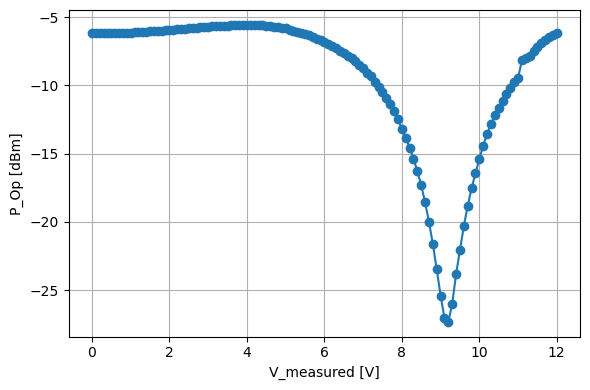

In [28]:
#%% Plot result of sweep

plt.figure(figsize=(6,4))

x = df_voltage_sweep["V_measured"]
y = df_voltage_sweep["P_Op_dBm"]

plt.plot(x, y, 'o-')

plt.xlabel("V_measured [V]")
plt.ylabel("P_Op [dBm]")
plt.tight_layout()
plt.grid()
plt.show()

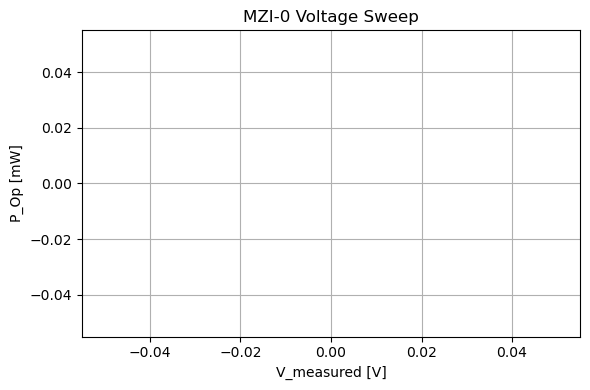

In [145]:

plt.figure(figsize=(6,4))

x = df_voltage_sweep["V_measured"]
y = df_voltage_sweep["P_Op_mW"]

plt.plot(x, y, 'o')

plt.xlabel("V_measured [V]")
plt.ylabel("P_Op [mW]")
plt.title("MZI-0 Voltage Sweep")
plt.tight_layout()
plt.grid()
plt.show()

In [84]:
pi_ps = np.argmin(df_voltage_sweep["P_Op_mW"])
zero_ps = np.argmax(df_voltage_sweep["P_Op_mW"])
print(f"Zero phase shift at V = {df_voltage_sweep.index[zero_ps]:.3f} V, Pi phase shift at V = {df_voltage_sweep.index[pi_ps]:.3f} V")

Zero phase shift at V = 4.100 V, Pi phase shift at V = 10.300 V


In [123]:
q.set_v(11, 4.1)

In [85]:
# Visibility
visibility = (df_voltage_sweep["P_Op_mW"].max() - df_voltage_sweep["P_Op_mW"].min()) / (df_voltage_sweep["P_Op_mW"].max() + df_voltage_sweep["P_Op_mW"].min())
print(f"Visibility: {visibility:.4f}")

Visibility: 0.9874


In [86]:
df_voltage_sweep["P_Op_dBm"].min()-df_voltage_sweep["P_Op_dBm"].max()

np.float64(-21.994579869168923)

In [79]:
df_voltage_sweep["P_Op_dBm"].min()

np.float64(-14.01546663953144)

In [88]:
(5500000-300000)/5800000

0.896551724137931

In [134]:
import pandas as pd

data = pd.read_csv(r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\coinc_hist_bwidth2_nbins1000_30s_sifilt70g_pfilt70g.txt", sep="\t", header=0)

data.head()

,Time differences (ps),Counts per bin
0,-1000,4
1,-998,5
2,-996,9
3,-994,2
4,-992,4


In [137]:
data[data["Counts per bin"]==data["Counts per bin"].max()]

,Time differences (ps),Counts per bin
499,-2,2289


In [142]:
half_window = 12

side_peaks_centers = [99, 299, 699, 899]

integrals = []
for center in side_peaks_centers:
    start = max(center - half_window, 0)
    end = min(center + half_window + 1, len(data))
    integral = data["Counts per bin"][start:end].sum()
    integrals.append(float(integral))

central_peak_integral = data["Counts per bin"][499-half_window:499+half_window+1].sum()
print(f"Central peak integral: {central_peak_integral}")
print(f"Side peaks integrals: {integrals}")

Central peak integral: 42057
Side peaks integrals: [1517.0, 1570.0, 1646.0, 1634.0]


In [ ]:
correct_background = [i for i in []]

np.mean(integrals) / central_peak_integral

np.float64(0.03784744513398483)